# Hyperparameter Posterior Probability Distributions

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [31]:
hyperparameters = pd.read_csv('hyperparameter_samples.csv', header=None)
hyperparameters = hyperparameters.to_numpy()

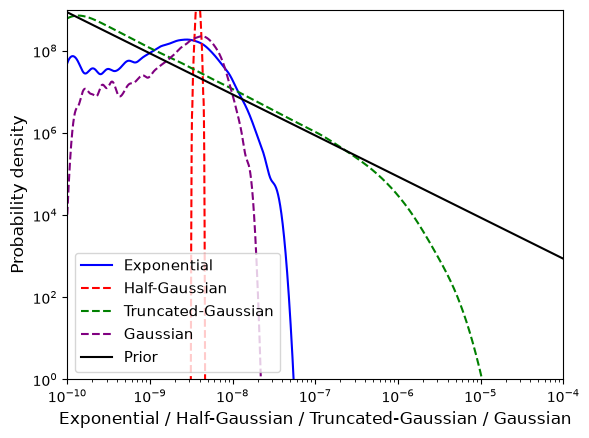

In [32]:
x_grid = np.logspace(-10,-4, 12000)
log10_x_grid = np.log10(x_grid)

samples_expo = hyperparameters[0]
samples_half_gauss = hyperparameters[1]
samples_trunc_gauss = hyperparameters[2]
samples_gauss = hyperparameters[3]


prior_min, prior_max = 1e-10,1e-5

def compute_density(samples, grid, log_grid):
    log10_samples = np.log10(samples)
    kde = gaussian_kde(log10_samples)
    
    density_log10 = kde(log_grid)
    
    density_linear = density_log10 / (grid * np.log(10))
    return density_linear

density_expo = compute_density(samples_expo, x_grid, log10_x_grid)
density_hg = compute_density(samples_half_gauss, x_grid, log10_x_grid)
density_tg = compute_density(samples_trunc_gauss, x_grid, log10_x_grid)
density_g = compute_density(samples_gauss, x_grid, log10_x_grid)


prior_density = 1.0 / (x_grid * np.log(prior_max / prior_min))



plt.plot(x_grid, density_expo, label='Exponential', color='blue', linestyle='-')
plt.plot(x_grid, density_hg, label='Half-Gaussian', color='red', linestyle='--')
plt.plot(x_grid, density_tg, label='Truncated-Gaussian', color='green', linestyle='--')
plt.plot(x_grid, density_g, label='Gaussian', color='purple', linestyle='--')


plt.plot(x_grid, prior_density, label='Prior', color='black', linestyle='-')

# Scale and Limits
plt.xscale('log')
plt.yscale('log')
plt.xlim(10**-10, 10**-4)
plt.ylim(1, 10**9)

# Labels and Styling
plt.xlabel('Exponential / Half-Gaussian / Truncated-Gaussian / Gaussian', fontsize=12)
plt.ylabel('Probability density', fontsize=12)
plt.legend(loc='lower left', fontsize=11)

plt.show()